In [1]:
import os
import random
os.chdir("..")


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from transformers import AutoTokenizer

from src.data_loader import load_json

pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
article_path = "data/articles.json"

articles = load_json(article_path)

## 1. Проверка дубликатов

In [3]:
print(f"Количество дубликатов в текстах: ", len(set([article['text'] for article in articles])) - len([article['text'] for article in articles]))
print(f"Количество дубликатов в топиках: ", len(set([article['title'] for article in articles])) - len([article['title'] for article in articles]))

Количество дубликатов в текстах:  0
Количество дубликатов в топиках:  0


## 2. Анализ длины документов

In [4]:
length_text, length_topic = [], []
for article in articles:
    length_text.append(len(article['text']))
    length_topic.append(len(article['title']))

print(f'Средняя длина заголовка: {np.mean(length_topic):.1f}')
print(f"Средняя длина текста: {np.mean(length_text):.1f}")
pd.DataFrame({'Длина текстов': length_text,
              'Длина топика': length_topic,
              'Отклонение от средней длины текста': (length_text - np.mean(length_text)) * 100 / np.mean(length_text), 
              'Отклонение от среднего длины топика': (length_topic - np.mean(length_topic)) * 100 / np.mean(length_topic)
              })

Средняя длина заголовка: 47.6
Средняя длина текста: 784.8


,Длина текстов,Длина топика,Отклонение от средней длины текста,Отклонение от среднего длины топика
0,866,55,10.35,15.55
1,823,49,4.87,2.94
2,730,41,-6.98,-13.87
3,805,52,2.57,9.24
4,772,43,-1.63,-9.66
5,728,50,-7.24,5.04
6,785,55,0.03,15.55
7,767,55,-2.27,15.55
8,754,32,-3.92,-32.77
9,818,44,4.23,-7.56


## 3. Анализ случайных документов

In [5]:
for article in random.sample(articles, 5):
    print(article['title'])
    print(article['text'])
    print('=' * 80)

Политика SLA службы технической поддержки
Служба поддержки обрабатывает обращения в четырех приоритетах: P1 критический, P2 высокий, P3 средний, P4 низкий. Для P1 целевое время первого ответа составляет 15 минут, время восстановления сервиса — до 4 часов. Для P2 первый ответ — 1 час, восстановление — 8 часов. Для P3 первый ответ — 4 часа, решение — 3 рабочих дня. Для P4 первый ответ — 1 рабочий день, решение — до 10 рабочих дней. Поддержка работает круглосуточно для P1 и P2, по графику 09:00-21:00 по Москве для P3 и P4. Если инцидент не может быть решен в установленный срок, дежурный инженер обязан инициировать эскалацию на Incident Manager не позднее чем за 30 минут до дедлайна SLA. Ежемесячная целевая метрика соблюдения SLA установлена на уровне 97,5 процента.
Политика удаленной работы и компенсации домашнего офиса
Сотрудники могут работать удаленно до 4 дней в неделю при сохранении присутствия в офисе в командный день, установленный руководителем. Компания компенсирует расходы на до

## 4. Анализ распределения токенов

Средняя количество токенов: 258.0
Максимальное количество токенов: 294


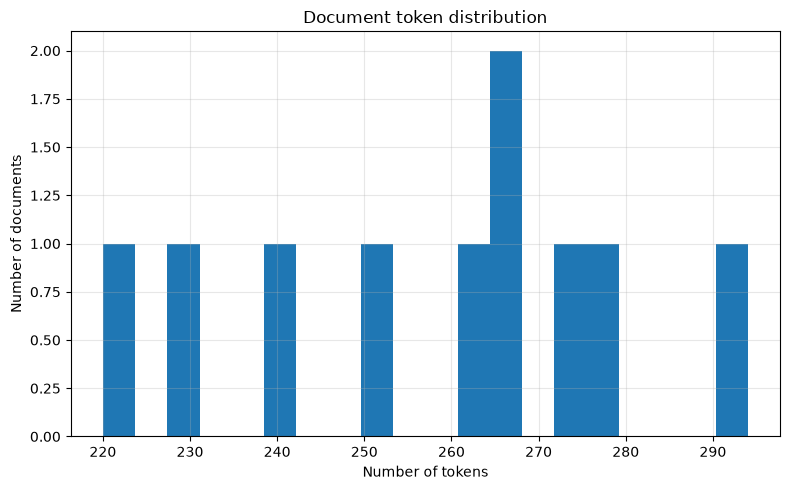

In [6]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-4b')

length_token = (
    [
        len(tokenizer.encode(article['text'], add_special_token=False)) 
        for article in articles
    ]
)

print(f'Средняя количество токенов: {np.mean(length_token):.1f}')
print(f'Максимальное количество токенов: {max(length_token)}')

plt.figure(figsize=(8, 5))

plt.hist(length_token, bins=20)

plt.title("Document token distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Number of documents")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Выводы

- Дубликаты в наборе данных отсутствуют.
- Документы имеют сопоставимый объём.
- При ручной проверке не обнаружено артефактов и шумовых данных.
- Распределение количества токенов не выявило экстремально длинных документов.
- На основе количества токенов было принято решение не бить документы на чанки